In [1]:
import numpy as np
import pandas as pd

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df = pd.read_csv('train.csv',usecols = ['Age','Fare','Survived'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [7]:
df.sample(10)

,Survived,Age,Fare
839,1,NaN,29.7000
577,1,39.0,55.9000
450,0,36.0,27.7500
236,0,44.0,26.0000
320,0,22.0,7.2500
660,1,50.0,133.6500
843,0,34.5,6.4375
4,0,35.0,8.0500
605,0,36.0,15.5500
560,0,NaN,7.7500


In [8]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].mean())


In [13]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

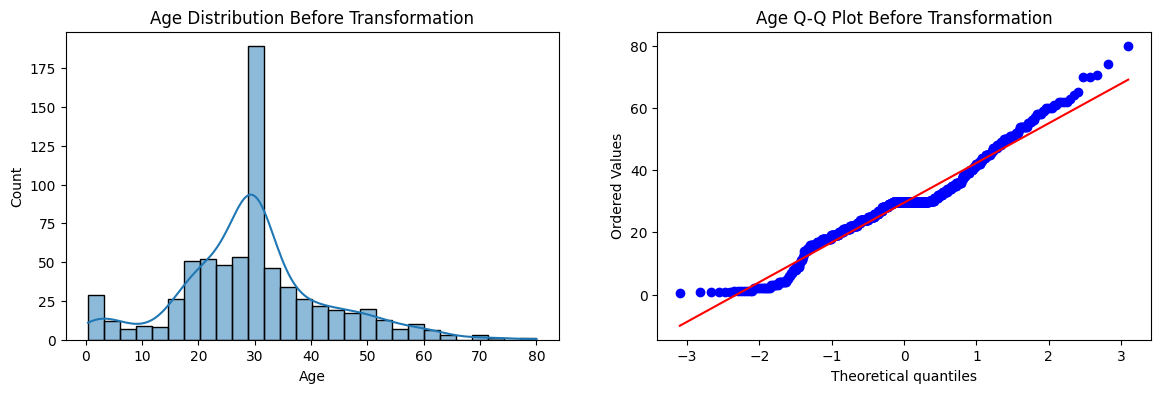

In [19]:
plt.figure(figsize = (14,4))
plt.subplot(121)
sns.histplot(X_train['Age'] , kde=True)
plt.title('Age Distribution Before Transformation')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Q-Q Plot Before Transformation')

plt.show()


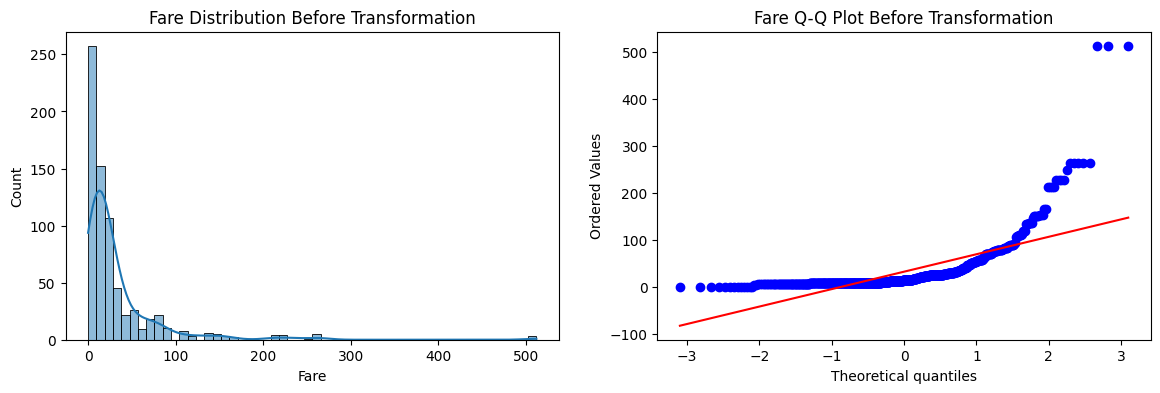

In [20]:
plt.figure(figsize = (14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'] , kde=True)
plt.title('Fare Distribution Before Transformation')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Q-Q Plot Before Transformation')

plt.show()


In [21]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()



In [22]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Logistic Regression Accuracy before Transformation: ", accuracy_score(y_test, y_pred))
print("Decision Tree Classifier Accuracy before Transformation: ", accuracy_score(y_test, y_pred1))


Logistic Regression Accuracy before Transformation:  0.6480446927374302
Decision Tree Classifier Accuracy before Transformation:  0.6759776536312849


In [ ]:
trf = FunctionTransformer(func=np.log1p) # np.log1p is used to handle zero values

In [24]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [27]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Logistic Regression Accuracy after Transformation: ", accuracy_score(y_test, y_pred))
print("Decision Tree Classifier Accuracy after Transformation: ", accuracy_score(y_test, y_pred1))

Logistic Regression Accuracy after Transformation:  0.6815642458100558
Decision Tree Classifier Accuracy after Transformation:  0.6815642458100558


# cross validation

In [33]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Logistic Regression Cross-Validation Scores after Transformation: ", np.mean(cross_val_score(clf, X_transformed, y,scoring = 'accuracy' ,cv=10)))
print("Decision Tree Classifier Cross-Validation Scores after Transformation: ", np.mean(cross_val_score(clf2, X_transformed, y,scoring = 'accuracy', cv=10)))

Logistic Regression Cross-Validation Scores after Transformation:  0.678027465667915
Decision Tree Classifier Cross-Validation Scores after Transformation:  0.6577528089887641


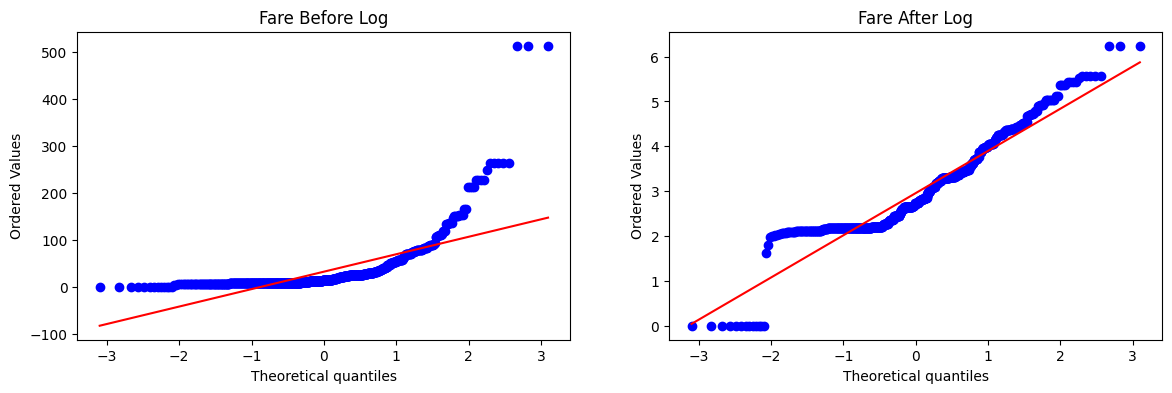

In [34]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()


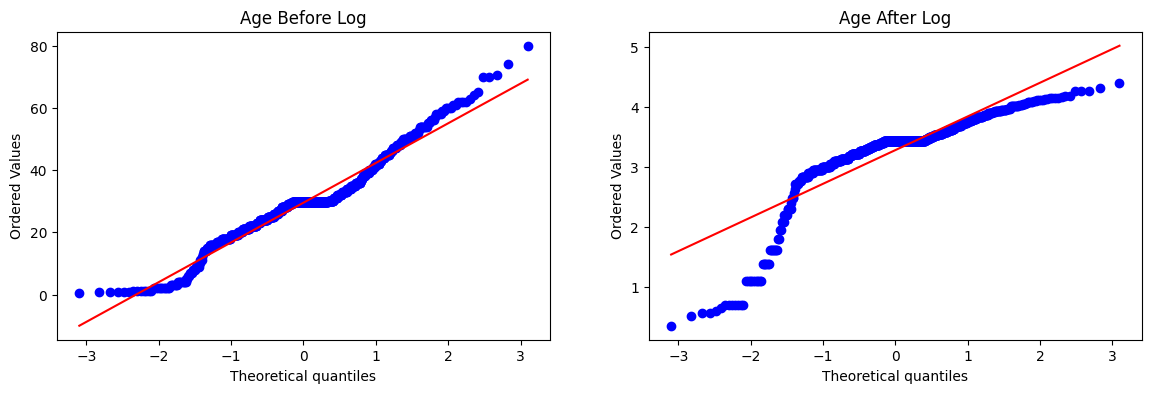

In [35]:

plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [36]:
trf2 = ColumnTransformer([('log_transform', FunctionTransformer(func=np.log1p), ['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [37]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))


Accuracy LR 0.6703910614525139
Accuracy DT 0.664804469273743


In [38]:

X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6610736579275904
